# M7-B1 — Mesures d audit (à compléter)

### 0. Chargement et aperçu des données

In [2]:
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data" / "dms_dataset.csv"

df = pd.read_csv(DATA_PATH)

display(df.head())
df.info()

,patient_id,age,sexe,departement,service,type_admission,nb_comorbidites,imc,dms_jours,sejour_prolonge
0,PAT-000000,24,F,85,geriatrie,urgence,0,26.8,4.0,0
1,PAT-000001,77,F,85,orthopedie,urgence,0,22.2,6.9,0
2,PAT-000002,68,M,44,medecine,urgence,2,28.8,5.6,1
3,PAT-000003,51,M,44,geriatrie,programme,2,22.6,6.3,1
4,PAT-000004,51,F,44,geriatrie,programme,1,27.4,9.6,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       10000 non-null  object 
 1   age              10000 non-null  int64  
 2   sexe             10000 non-null  object 
 3   departement      10000 non-null  int64  
 4   service          10000 non-null  object 
 5   type_admission   10000 non-null  object 
 6   nb_comorbidites  10000 non-null  int64  
 7   imc              10000 non-null  float64
 8   dms_jours        10000 non-null  float64
 9   sejour_prolonge  10000 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 781.4+ KB


#### Premières observations

- Le jeu de données contient 10 000 séjours et aucune valeur manquante.
- Les colonnes `sexe`, `departement`, `service` et `type_admission` sont des variables catégorielles, et non du texte libre.
- `patient_id` est un identifiant ; il ne doit pas être utilisé comme variable explicative.
- La cible est `sejour_prolonge`.
- Variable sensible : `sexe`
- Variable personnelle à surveiller pour l'équité : `age`
- Données de santé : `nb_comorbidites`, `imc`

count    10000.000000
mean        55.720100
std         22.120974
min         18.000000
25%         37.000000
50%         56.000000
75%         75.000000
max         94.000000
Name: age, dtype: float64

<Axes: title={'center': 'Répartition des âges (classes de 5 ans)'}, xlabel='Âge', ylabel='Nombre de séjours'>

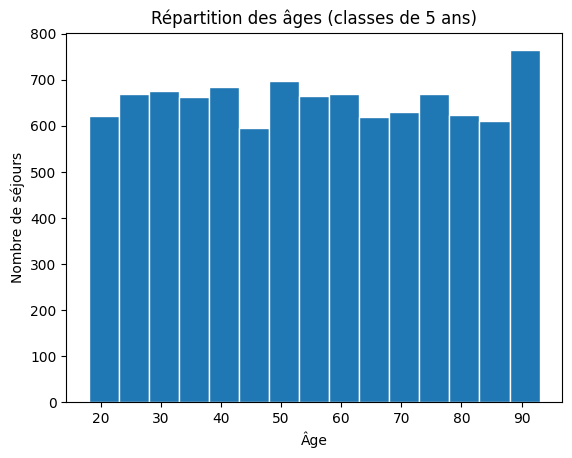

In [6]:
display(df["age"].describe())

# repartition_age = (
#     df["age"]
#     .value_counts()
#     .sort_index()
#     .rename_axis("age")
#     .reset_index(name="nombre_sejours")
# )

# display(repartition_age)

df["age"].plot(
    kind="hist",
    bins=range(int(df["age"].min()), int(df["age"].max()) + 2, 5),
    edgecolor="white",
    title="Répartition des âges (classes de 5 ans)",
    xlabel="Âge",
    ylabel="Nombre de séjours",
)

### 1. Disparate impact du modèle — puis investigation

DI sur prédictions et étiquettes, puis FNR/FPR et probabilité moyenne **par groupe** contre une référence construite depuis `dms_jours`.

In [3]:
import joblib

MODEL_PATH = ROOT / "legacy" / "dms_predictor_v1.joblib"
model = joblib.load(MODEL_PATH)

features = ["age", "nb_comorbidites", "imc"]
X = df[features].copy()
X["sexe_bin"] = (df["sexe"] == "M").astype(int)

df["prediction"] = model.predict(X)
df["probabilite"] = model.predict_proba(X)[:, 1]

In [4]:
taux_prediction = df.groupby("sexe")["prediction"].mean()
di_prediction_f_m = taux_prediction["F"] / taux_prediction["M"]

display(taux_prediction.to_frame("taux_prediction_positive"))
print(f"DI F/M sur les prédictions : {di_prediction_f_m:.3f}")

,taux_prediction_positive
sexe,
F,0.141489
M,0.485668


DI F/M sur les prédictions : 0.291


In [7]:
bornes_age = [10, 30, 50, 70, 90, 110]
labels_age = ["10-29 ans", "30-49 ans", "50-69 ans", "70-89 ans", "90 ans et plus"]

df["groupe_age"] = pd.cut(
    df["age"],
    bins=bornes_age,
    labels=labels_age,
    right=False,
)

display(
    df["groupe_age"]
    .value_counts()
    .reindex(labels_age)
    .rename("nombre_sejours")
    .to_frame()
)

,nombre_sejours
groupe_age,
10-29 ans,1568
30-49 ans,2609
50-69 ans,2637
70-89 ans,2558
90 ans et plus,628


In [8]:
taux_prediction_age = df.groupby("groupe_age", observed=True)["prediction"].mean()

display(taux_prediction_age.to_frame("taux_prediction_positive"))

,taux_prediction_positive
groupe_age,
10-29 ans,0.075255
30-49 ans,0.147949
50-69 ans,0.329920
70-89 ans,0.544175
90 ans et plus,0.582803


In [9]:
groupe_reference = taux_prediction_age.idxmax()
taux_reference = taux_prediction_age.max()

di_age_vs_groupe_favorable = (
    taux_prediction_age / taux_reference
).rename("DI_vs_groupe_le_plus_favorable")

print(f"Groupe de référence : {groupe_reference}")
print(f"Taux de prédictions positives : {taux_reference:.3f}")

display(di_age_vs_groupe_favorable.to_frame())

Groupe de référence : 90 ans et plus
Taux de prédictions positives : 0.583


,DI_vs_groupe_le_plus_favorable
groupe_age,
10-29 ans,0.129126
30-49 ans,0.253859
50-69 ans,0.566093
70-89 ans,0.933721
90 ans et plus,1.000000


In [10]:
# Analyse du DI sur les données
taux_prediction_sexe = df.groupby("sexe")["prediction"].mean()
taux_etiquette_sexe = df.groupby("sexe")["sejour_prolonge"].mean()

di_prediction_f_m = (
    taux_prediction_sexe["F"] / taux_prediction_sexe["M"]
)
di_etiquette_f_m = (
    taux_etiquette_sexe["F"] / taux_etiquette_sexe["M"]
)

comparaison_di = pd.DataFrame(
    {
        "taux_prediction_positive": taux_prediction_sexe,
        "taux_etiquette_sejour_prolonge": taux_etiquette_sexe,
    }
)

display(comparaison_di)

print(f"DI F/M sur les prédictions : {di_prediction_f_m:.3f}")
print(f"DI F/M sur les étiquettes : {di_etiquette_f_m:.3f}")
print(f"Écart modèle - étiquette : {di_prediction_f_m - di_etiquette_f_m:+.3f}")

,taux_prediction_positive,taux_etiquette_sejour_prolonge
sexe,,
F,0.141489,0.320694
M,0.485668,0.491481


DI F/M sur les prédictions : 0.291
DI F/M sur les étiquettes : 0.653
Écart modèle - étiquette : -0.361


In [11]:
# Comparaison du DI par groupe d'âge : prédictions vs étiquettes

taux_etiquette_age = (
    df.groupby("groupe_age", observed=True)["sejour_prolonge"]
    .mean()
)

di_prediction_age = (
    taux_prediction_age / taux_prediction_age.max()
).rename("DI_prediction_vs_groupe_favorable")

di_etiquette_age = (
    taux_etiquette_age / taux_etiquette_age.max()
).rename("DI_etiquette_vs_groupe_favorable")

comparaison_di_age = pd.concat(
    [
        taux_prediction_age.rename("taux_prediction_positive"),
        taux_etiquette_age.rename("taux_etiquette_sejour_prolonge"),
        di_prediction_age,
        di_etiquette_age,
    ],
    axis=1,
)

display(comparaison_di_age.round(3))

print(
    "Groupe de référence des prédictions : "
    f"{taux_prediction_age.idxmax()}"
)
print(
    "Groupe de référence des étiquettes : "
    f"{taux_etiquette_age.idxmax()}"
)

,taux_prediction_positive,taux_etiquette_sejour_prolonge,DI_prediction_vs_groupe_favorable,DI_etiquette_vs_groupe_favorable
groupe_age,,,,
10-29 ans,0.075,0.242,0.129,0.434
30-49 ans,0.148,0.307,0.254,0.552
50-69 ans,0.330,0.430,0.566,0.771
70-89 ans,0.544,0.545,0.934,0.979
90 ans et plus,0.583,0.557,1.000,1.000


Groupe de référence des prédictions : 90 ans et plus
Groupe de référence des étiquettes : 90 ans et plus


### Corrélation avec la durée réelle dms_jour

In [12]:
display(
    df.groupby(["sexe", "sejour_prolonge"])["dms_jours"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(
    df.groupby(["groupe_age", "sejour_prolonge"], observed=True)["dms_jours"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

count  mean  median  min   max
sexe sejour_prolonge                                
F    0                 3404  4.68     4.5  1.0  14.9
     1                 1607  7.61     7.3  5.6  14.3
M    0                 2537  3.63     3.8  1.0   5.5
     1                 2452  7.61     7.3  5.6  15.3

count  mean  median  min   max
groupe_age     sejour_prolonge                                
10-29 ans      0                 1189  3.55     3.5  1.0  11.8
               1                  379  7.12     6.8  5.6  13.1
30-49 ans      0                 1807  3.86     3.9  1.0  12.1
               1                  802  7.30     7.0  5.6  12.7
50-69 ans      0                 1504  4.46     4.4  1.0  13.0
               1                 1133  7.52     7.2  5.6  15.3
70-89 ans      0                 1163  4.92     4.8  1.0  11.9
               1                 1395  7.89     7.6  5.6  15.1
90 ans et plus 0                  278  5.54     5.1  1.3  14.9
               1                  350  8.01     7.7  5.6  13.6

In [24]:
SEUIL_DMS_JOURS = 7

df["sejour_long_reference"] = (
    df["dms_jours"] >= SEUIL_DMS_JOURS
).astype(int)

display(
    df.groupby("sexe")["sejour_long_reference"]
    .mean()
    .rename("taux_sejour_long_reference")
    .to_frame()
)

,taux_sejour_long_reference
sexe,
F,0.293953
M,0.290239


In [25]:
comparaison_sexe_reference = df.groupby("sexe").agg(duree_moyenne_reelle=("dms_jours", "mean"),
                                                    duree_mediane_reelle=("dms_jours", "median"),
                                                    taux_reference=("sejour_long_reference", "mean"),
                                                    taux_etiquette=("sejour_prolonge", "mean"),
                                                    taux_prediction=("prediction", "mean"),
                                                    proba_moyenne=("probabilite", "mean"))

display(comparaison_sexe_reference.round(3))

,duree_moyenne_reelle,duree_mediane_reelle,taux_reference,taux_etiquette,taux_prediction,proba_moyenne
sexe,,,,,,
F,5.620,5.6,0.294,0.321,0.141,0.321
M,5.585,5.5,0.290,0.491,0.486,0.491


In [26]:
comparaison_age_reference = df.groupby(
    "groupe_age", observed=True
).agg(
    duree_moyenne_reelle=("dms_jours", "mean"),
    duree_mediane_reelle=("dms_jours", "median"),
    taux_reference=("sejour_long_reference", "mean"),
    taux_etiquette=("sejour_prolonge", "mean"),
    taux_prediction=("prediction", "mean"),
    proba_moyenne=("probabilite", "mean"),
)

display(comparaison_age_reference.round(3))

,duree_moyenne_reelle,duree_mediane_reelle,taux_reference,taux_etiquette,taux_prediction,proba_moyenne
groupe_age,,,,,,
10-29 ans,4.411,4.3,0.138,0.242,0.075,0.242
30-49 ans,4.913,4.8,0.192,0.307,0.148,0.305
50-69 ans,5.773,5.8,0.306,0.430,0.330,0.430
70-89 ans,6.539,6.5,0.428,0.545,0.544,0.544
90 ans et plus,6.914,6.8,0.479,0.557,0.583,0.563


### 2. Ressources (psutil)

In [32]:
# Calcul des grandeurs sur le modèle legacy

import gc
import os
import time
from pathlib import Path

import psutil
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

MODEL_PATH = ROOT / "legacy" / "dms_predictor_v1.joblib"
VOLUMES = [100, 1_000, 10_000]
N_REPETITIONS = 20

proc = psutil.Process(os.getpid())
taille_modele_mo = MODEL_PATH.stat().st_size / 1e6

# Mesure de l'entraînement du modèle legacy sans écraser le fichier .joblib fourni.
gc.collect()
rss_avant_train_mo = proc.memory_info().rss / 1e6

modele_mesure = RandomForestClassifier(
    n_estimators=60,
    max_depth=10,
    random_state=0,
)

debut_train = time.perf_counter()
modele_mesure.fit(X, df["sejour_prolonge"])
temps_train_s = time.perf_counter() - debut_train

rss_apres_train_mo = proc.memory_info().rss / 1e6

# Mesure répétée de l'inférence pour limiter l'effet du bruit de mesure.
resultats_inference = []

for volume in VOLUMES:
    X_lot = X.iloc[:volume]

    # Échauffement : charge les structures internes avant la mesure.
    model.predict(X_lot)

    durees_ms = []
    for _ in range(N_REPETITIONS):
        debut_inference = time.perf_counter()
        model.predict(X_lot)
        durees_ms.append((time.perf_counter() - debut_inference) * 1_000)

    resultats_inference.append(
        {
            "volume": volume,
            "inference_mediane_ms": sorted(durees_ms)[N_REPETITIONS // 2],
            "inference_min_ms": min(durees_ms),
            "inference_max_ms": max(durees_ms),
            "ms_par_sejour": sorted(durees_ms)[N_REPETITIONS // 2] / volume,
        }
    )

mesures_inference = pd.DataFrame(resultats_inference)

resume_ressources = pd.DataFrame(
    {
        "indicateur": [
            "taille_modele_mo",
            "rss_avant_train_mo",
            "rss_apres_train_mo",
            "variation_rss_train_mo",
            "temps_entrainement_s",
        ],
        "valeur": [
            taille_modele_mo,
            rss_avant_train_mo,
            rss_apres_train_mo,
            rss_apres_train_mo - rss_avant_train_mo,
            temps_train_s,
        ],
    }
)

display(resume_ressources.round(3))
display(mesures_inference.round(4))

,indicateur,valeur
0,taille_modele_mo,4.956
1,rss_avant_train_mo,216.777
2,rss_apres_train_mo,216.506
3,variation_rss_train_mo,-0.270
4,temps_entrainement_s,0.303


,volume,inference_mediane_ms,inference_min_ms,inference_max_ms,ms_par_sejour
0,100,2.9471,2.4634,4.2706,0.0295
1,1000,7.9474,7.5838,9.3379,0.0079
2,10000,47.2290,45.1095,52.2635,0.0047


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    df["sejour_prolonge"],
    test_size=0.2,
    random_state=0,
    stratify=df["sejour_prolonge"],
)

In [36]:
f1_legacy_test = f1_score(y_test, model.predict(X_test))
print(f"F1 legacy sur le jeu de test : {f1_legacy_test:.3f}")

F1 legacy sur le jeu de test : 0.691


### 3. Comparaison à 2 alternatives

### 1ere alternative HistGradientBoosting

In [37]:
# Entrainement d'un modèle alternatif pour comparer les métriques
import gc
import os
import tempfile
import time
from pathlib import Path

import joblib
import psutil
from sklearn.ensemble import HistGradientBoostingClassifier

os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

proc = psutil.Process(os.getpid())
VOLUMES = [100, 1_000, 10_000]
N_REPETITIONS = 20

# Entraînement et mesure des ressources
gc.collect()
rss_avant_train_mo = proc.memory_info().rss / 1e6

histgb = HistGradientBoostingClassifier(random_state=0)

debut_train = time.perf_counter()
histgb.fit(X_train, y_train)
temps_train_s = time.perf_counter() - debut_train

rss_apres_train_mo = proc.memory_info().rss / 1e6

# Performance sur le jeu de test non utilisé pour l'entraînement
prediction_test = histgb.predict(X_test)
f1_test = f1_score(y_test, prediction_test)

# Taille du modèle sans ajouter de fichier permanent au projet
with tempfile.TemporaryDirectory() as dossier_temporaire:
    chemin_modele = Path(dossier_temporaire) / "histgb.joblib"
    joblib.dump(histgb, chemin_modele)
    taille_modele_mo = chemin_modele.stat().st_size / 1e6

# Inférence répétée sur les mêmes volumes que le modèle legacy
resultats_inference_histgb = []

for volume in VOLUMES:
    X_lot = X.iloc[:volume]

    # Échauffement
    histgb.predict(X_lot)

    durees_ms = []
    for _ in range(N_REPETITIONS):
        debut_inference = time.perf_counter()
        histgb.predict(X_lot)
        durees_ms.append((time.perf_counter() - debut_inference) * 1_000)

    durees_ms.sort()

    resultats_inference_histgb.append(
        {
            "modele": "HistGradientBoosting",
            "volume": volume,
            "inference_mediane_ms": durees_ms[N_REPETITIONS // 2],
            "inference_min_ms": min(durees_ms),
            "inference_max_ms": max(durees_ms),
            "ms_par_sejour": durees_ms[N_REPETITIONS // 2] / volume,
        }
    )

resume_histgb = pd.DataFrame(
    {
        "modele": ["HistGradientBoosting"],
        "f1_test": [f1_test],
        "temps_entrainement_s": [temps_train_s],
        "rss_avant_train_mo": [rss_avant_train_mo],
        "rss_apres_train_mo": [rss_apres_train_mo],
        "variation_rss_train_mo": [rss_apres_train_mo - rss_avant_train_mo],
        "taille_modele_mo": [taille_modele_mo],
    }
)

inference_histgb = pd.DataFrame(resultats_inference_histgb)

display(resume_histgb.round(4))
display(inference_histgb.round(4))


,modele,f1_test,temps_entrainement_s,rss_avant_train_mo,rss_apres_train_mo,variation_rss_train_mo,taille_modele_mo
0,HistGradientBoosting,0.5815,0.3501,216.9897,217.0061,0.0164,0.3661


,modele,volume,inference_mediane_ms,inference_min_ms,inference_max_ms,ms_par_sejour
0,HistGradientBoosting,100,3.8607,2.9217,6.9108,0.0386
1,HistGradientBoosting,1000,4.3452,3.0231,6.2399,0.0043
2,HistGradientBoosting,10000,18.4628,15.0194,43.4892,0.0018


### 2eme alternative : XGBoost

In [38]:
import gc
import tempfile
import time
from pathlib import Path

import joblib
import psutil
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

proc = psutil.Process(os.getpid())
VOLUMES = [100, 1_000, 10_000]
N_REPETITIONS = 20

# Paramètres volontairement proches du modèle legacy :
# 60 arbres, profondeur maximale 10.
gc.collect()
rss_avant_train_xgb_mo = proc.memory_info().rss / 1e6

xgb = XGBClassifier(
    n_estimators=60,
    max_depth=10,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    eval_metric="logloss",
    random_state=0,
    n_jobs=1,
    tree_method="hist",
    verbosity=0,
)

debut_train_xgb = time.perf_counter()
xgb.fit(X_train, y_train)
temps_train_xgb_s = time.perf_counter() - debut_train_xgb

rss_apres_train_xgb_mo = proc.memory_info().rss / 1e6

prediction_test_xgb = xgb.predict(X_test)
f1_test_xgb = f1_score(y_test, prediction_test_xgb)

with tempfile.TemporaryDirectory() as dossier_temporaire:
    chemin_modele_xgb = Path(dossier_temporaire) / "xgboost.joblib"
    joblib.dump(xgb, chemin_modele_xgb)
    taille_modele_xgb_mo = chemin_modele_xgb.stat().st_size / 1e6

resultats_inference_xgb = []

for volume in VOLUMES:
    X_lot = X.iloc[:volume]
    xgb.predict(X_lot)  # échauffement

    durees_ms = []
    for _ in range(N_REPETITIONS):
        debut_inference = time.perf_counter()
        xgb.predict(X_lot)
        durees_ms.append((time.perf_counter() - debut_inference) * 1_000)

    durees_ms.sort()

    resultats_inference_xgb.append(
        {
            "modele": "XGBoost",
            "volume": volume,
            "inference_mediane_ms": durees_ms[N_REPETITIONS // 2],
            "inference_min_ms": min(durees_ms),
            "inference_max_ms": max(durees_ms),
            "ms_par_sejour": durees_ms[N_REPETITIONS // 2] / volume,
        }
    )

resume_xgb = pd.DataFrame(
    {
        "modele": ["XGBoost"],
        "f1_test": [f1_test_xgb],
        "temps_entrainement_s": [temps_train_xgb_s],
        "rss_avant_train_mo": [rss_avant_train_xgb_mo],
        "rss_apres_train_mo": [rss_apres_train_xgb_mo],
        "variation_rss_train_mo": [
            rss_apres_train_xgb_mo - rss_avant_train_xgb_mo
        ],
        "taille_modele_mo": [taille_modele_xgb_mo],
    }
)

inference_xgb = pd.DataFrame(resultats_inference_xgb)

display(resume_xgb.round(4))
display(inference_xgb.round(4))

,modele,f1_test,temps_entrainement_s,rss_avant_train_mo,rss_apres_train_mo,variation_rss_train_mo,taille_modele_mo
0,XGBoost,0.5494,0.237,221.7574,341.2541,119.4967,0.9709


,modele,volume,inference_mediane_ms,inference_min_ms,inference_max_ms,ms_par_sejour
0,XGBoost,100,1.0534,0.9449,1.2931,0.0105
1,XGBoost,1000,2.5245,2.3218,2.9492,0.0025
2,XGBoost,10000,14.1868,13.5726,20.0050,0.0014


In [39]:
print(resume_xgb.to_string(index=False))
print(inference_xgb.to_string(index=False))

 modele  f1_test  temps_entrainement_s  rss_avant_train_mo  rss_apres_train_mo  variation_rss_train_mo  taille_modele_mo
XGBoost 0.549379              0.237017           221.75744          341.254144              119.496704          0.970868
 modele  volume  inference_mediane_ms  inference_min_ms  inference_max_ms  ms_par_sejour
XGBoost     100                1.0534            0.9449            1.2931       0.010534
XGBoost    1000                2.5245            2.3218            2.9492       0.002525
XGBoost   10000               14.1868           13.5726           20.0050       0.001419
